# 03. Latent country means for the confounded covariates

Notebook 02 showed that a country intercept and a covariate that varies between countries compete for the same variance. 95% of GDP per capita is between-country, so once every country has its own intercept the coefficient is left with growth over time, which is collinear with the square of GDP and with CO2. The classical repair is Mundlak's: put each covariate's country mean in the model with its own coefficient. This notebook does the same thing generatively, in the spirit of McElreath's latent Mundlak machine from lecture 12 of Statistical Rethinking, with one change forced by the data.

McElreath's machine has one unobserved scalar per country generating every cross-sectional covariate and the count. That form was fit first here and did not sample, and the diagnostics section says why. The version kept has one latent per confounded covariate, three per country, with a 3 by 3 covariance across countries that estimates how much they move together. Each latent is that covariate's country mean as a parameter with its own uncertainty, its coefficient in the count model is the between-country effect, and what is left on the covariate is its within-country effect. The country intercept holds what neither explains. The square of GDP is dropped: within a country it is a copy of the level.

Sections follow the workflow: the data, the model, what the priors imply, the fit, its diagnostics, what the posterior predicts, between against within, the posterior against the prior, the comparison with notebooks 01 and 02, and what was learned.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from arviz_plots import plot_energy, plot_forest
from checks import (
    count_summaries,
    observed_count_summaries,
    plot_country_counts,
    plot_coverage,
    plot_posterior_with_prior,
    plot_predictive_summaries,
    plot_rootograms,
    summarize,
)

from climate_risk.plotting import configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}

# The paper's covariates with population logged, less the square of GDP per capita.
FEATURES = [("ln_population" if name == "population" else name)
            for name in MODEL_FEATURES if name != "square_ln_gdp_pc"]

# The covariates a latent generates: those that vary between countries. Precipitation deviation
# and CO2 are within-country by construction, so a country-level latent has nothing to say about
# them.
CONFOUNDED = ["ln_population", "ln_population_density", "ln_gdp_pc"]

## The data

The same panel as notebooks 01 and 02, standardized the same way. The table repeats the variance split from notebook 02 for the covariates kept here: it is what decides which of them get a latent country mean.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]))
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

codes = sorted(panel["iso"].unique())
country_idx = panel["iso"].map({code: position for position, code in enumerate(codes)}).to_numpy()

country_means = scaled[SCALED_FEATURES].groupby(panel["iso"]).transform("mean")
variance_split = pd.DataFrame({"between": country_means.var().to_numpy(),
                               "within": (scaled[SCALED_FEATURES] - country_means).var().to_numpy()},
                              index=FEATURES)

print(f"{len(panel)} country-years, {len(codes)} countries, "
      f"{panel['date'].dt.year.min()} to {panel['date'].dt.year.max()}")
variance_split.round(2)

7710 country-years, 199 countries, 1981 to 2023


,between,within
ln_population_density,0.97,0.03
ln_gdp_pc,0.95,0.05
precip_deviation,0.07,0.93
co2,0.05,0.95
ln_population,0.99,0.01


## The model

Per class $c$, country $j$, country-year $i$ in country $j$, and confounded covariate $k$,

$$
\begin{aligned}
u_j &\sim \operatorname{MvNormal}(0,\ \Sigma), \quad u_j \in \mathbb{R}^3 \\
x_{ik} &\sim \operatorname{Normal}(u_{jk},\ \sigma^{X}_k) \\
y_{ic} &\sim \operatorname{NegativeBinomial}(\mu_{ic},\ \alpha_c) \\
\log \mu_{ic} &= a_c + v_{jc} + \tilde{x}_i^\top \beta^{W}_c + u_j^\top \beta^{B}_c \\
v_{jc} &\sim \operatorname{Normal}(0,\ \tau_c)
\end{aligned}
$$

$u_j$ is a vector of three latents per country, one per confounded covariate: the country's mean of that covariate, as a parameter with its own uncertainty, in place of the sample mean a Mundlak regression plugs in. The three share a covariance $\Sigma$ across countries, 3 by 3, with the 199 countries as independent draws from it. Its diagonal is how far each covariate's country means spread, and its off-diagonal is whether the three move together across countries, which is the question a single latent confound would assume the answer to. A single latent with loadings is the rank-one case of this $\Sigma$, and independent latents the diagonal case.

Each latent generates its covariate through the measurement model on $x_{ik}$, whose residual $\sigma^{X}_k$ is the within-country variation. The covariates are standardized, so their grand mean is zero and the latents carry the location outright. $\tilde{x}_i$ is the covariate vector with each confounded column replaced by its deviation from the latent, $x_{ik} - u_{jk}$, and the other columns as they are. So $\beta^{W}_c$ is the within-country effect, $\beta^{B}_c$ the between-country one, and the country intercept $v_{jc}$ holds what neither explains. When $\beta^{B}_c$ equals $\beta^{W}_c$ the model is notebook 02 without the square.

$\Sigma$ carries an LKJ prior with concentration 2 on the correlations and `HalfNormal(1)` on the scales. Both coefficient vectors carry the `Normal(0, 0.5)` prior of the earlier notebooks and the rest are as in notebook 02. The latents are centered: 43 rows a country pin each one tightly, so the offset form would fight its own scale.

In [4]:
coords = {
    "obs_idx": panel.index,
    "iso": codes,
    "disaster": CLASSES,
    "feature": FEATURES,
    "confounded": CONFOUNDED,
    "confounded_": CONFOUNDED,
}
confounded_positions = [FEATURES.index(name) for name in CONFOUNDED]

with pm.Model(coords=coords) as latent_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])
    country = pm.Data("country", country_idx, dims=["obs_idx"])

    # The covariates are standardized, so the latents carry the whole location: a free grand mean would trade
    # against them.
    latent_chol, latent_corr, latent_scale = pm.LKJCholeskyCov("latent_cov",
                                                              n=len(CONFOUNDED),
                                                              eta=2,
                                                              sd_dist=pm.HalfNormal.dist(1),
                                                              compute_corr=True)
    latent = pm.MvNormal("latent", mu=0, chol=latent_chol, dims=["iso", "confounded"])
    pm.Deterministic("latent_corr", latent_corr, dims=["confounded", "confounded_"])
    pm.Deterministic("latent_scale", latent_scale, dims=["confounded"])

    sigma_X = pm.Exponential("sigma_X", 1, dims=["confounded"])
    pm.Normal("X_hat",
              mu=latent[country],
              sigma=sigma_X,
              observed=X[:, confounded_positions],
              dims=["obs_idx", "confounded"])

    # The confounded columns enter the count as deviations from their latent, the rest as they are.
    X_within = pt.set_subtensor(X[:, confounded_positions], X[:, confounded_positions] - latent[country])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta_within = pm.Normal("beta_within", 0, 0.5, dims=["feature", "disaster"])
    beta_between = pm.Normal("beta_between", 0, 0.5, dims=["confounded", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])

    tau = pm.HalfNormal("tau", 1, dims=["disaster"])
    country_offset = pm.Normal("country_offset", 0, 1, dims=["iso", "disaster"])
    country_effect = pm.Deterministic("country_effect", tau * country_offset, dims=["iso", "disaster"])

    log_mu = intercept + country_effect[country] + X_within @ beta_within + latent[country] @ beta_between
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims=["obs_idx", "disaster"])

    pm.NegativeBinomial("y",
                        mu=mu,
                        alpha=alpha,
                        observed=counts.to_numpy(),
                        dims=["obs_idx", "disaster"])

latent_model

## What the priors imply

The same three summaries as before, for the counts. The three latents add a term with a `HalfNormal(1)` scale and a `Normal(0, 0.5)` coefficient each to the log count, which widens the prior predictive a little beyond notebook 02.

Sampling: [X_hat, alpha, beta_between, beta_within, country_offset, intercept, latent, latent_cov, sigma_X, tau, y]


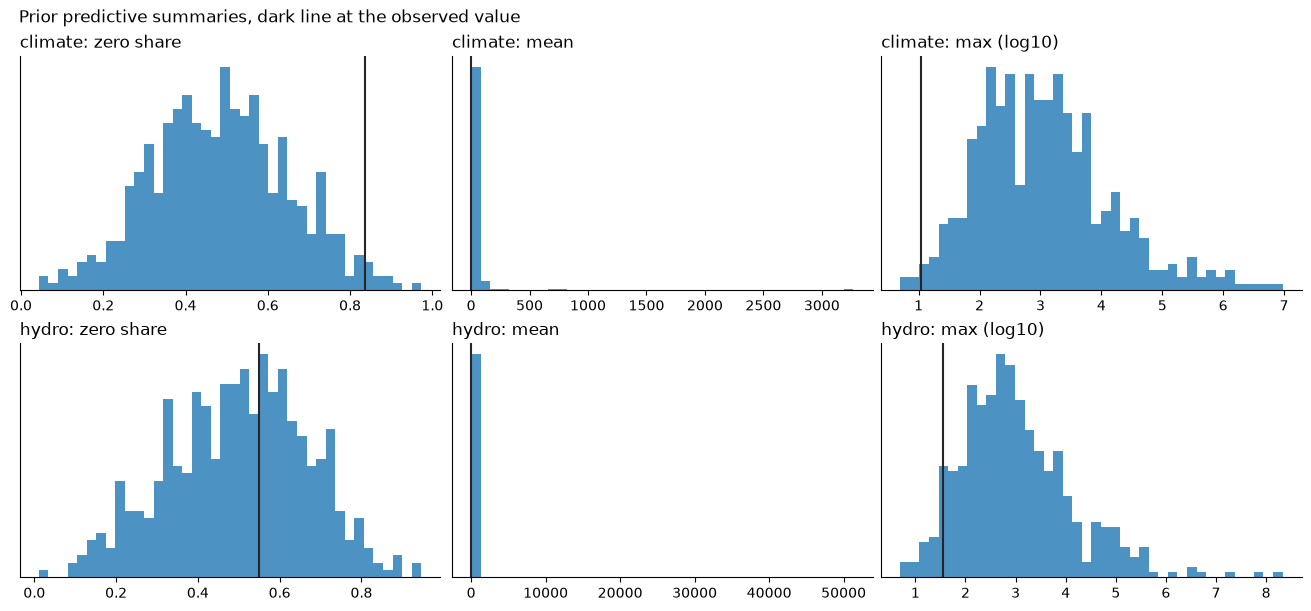

In [5]:
with latent_model:
    prior_idata = pm.sample_prior_predictive(draws=500, random_seed=SEED)

observed_summaries = observed_count_summaries(counts)
plot_predictive_summaries(count_summaries(prior_idata.prior_predictive["y"]),
                          observed_summaries,
                          CLASSES,
                          "Prior predictive summaries, dark line at the observed value")

## The fit

The draws land in `fits/`, which is gitignored. `sample_or_load` reads the file back when it exists and does not check that the saved draws came from the data now in memory, so a fit outlives any change to the panel or the feature list. Pass `force_resample=True` after one.

In [6]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     random_seed=SEED)

with latent_model:
    idata = sample_or_load(fp=str(FIT_DIR / "latent_confound.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta_within", "beta_between", "latent_scale", "sigma_X", "alpha", "tau"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.30,0.07,-2.42,-2.19,463.52,735.37,1.01,0.00,0.00
intercept[hydro],-0.68,0.07,-0.78,-0.59,84.41,170.52,1.07,0.01,0.01
"beta_within[ln_population_density, climate]",-0.33,0.32,-0.86,0.17,782.72,1038.92,1.01,0.01,0.01
"beta_within[ln_population_density, hydro]",1.16,0.28,0.72,1.60,337.21,600.16,1.02,0.01,0.01
"beta_within[ln_gdp_pc, climate]",-0.13,0.15,-0.36,0.12,1241.40,1130.08,1.01,0.00,0.00
"beta_within[ln_gdp_pc, hydro]",-0.08,0.07,-0.19,0.04,987.22,1324.46,1.01,0.00,0.00
"beta_within[precip_deviation, climate]",-0.39,0.04,-0.45,-0.33,2089.95,1438.77,1.00,0.00,0.00
"beta_within[precip_deviation, hydro]",0.24,0.01,0.22,0.26,2213.30,1639.92,1.00,0.00,0.00
"beta_within[co2, climate]",0.29,0.05,0.21,0.36,952.22,1114.78,1.01,0.00,0.00
"beta_within[co2, hydro]",0.10,0.03,0.06,0.15,739.21,1129.98,1.01,0.00,0.00


## Diagnostics

The GDP coefficient in notebook 02 mixed at a bulk ESS of 46 and an r_hat of 1.12. With the square gone and the cross-sectional part of each covariate handed to its latent, the within coefficients should no longer be fighting the intercepts. The 597 latents and the six numbers in their covariance are the new parameters to watch.

A single latent with loadings on every covariate, McElreath's form of this machine, was fit first on this panel and did not sample: eight chains landed in three modes, each with the latent standing in for a different one of population, density, and GDP per capita, with the anchored loading piled against zero in six of them. The three covariates do not share a factor across these 199 countries, so a single latent has no common direction to point in. The covariance $\Sigma$ leaves that to the data.

0 divergences; worst r_hat 1.101; smallest bulk ESS 66 (country_offset[PHL, hydro])


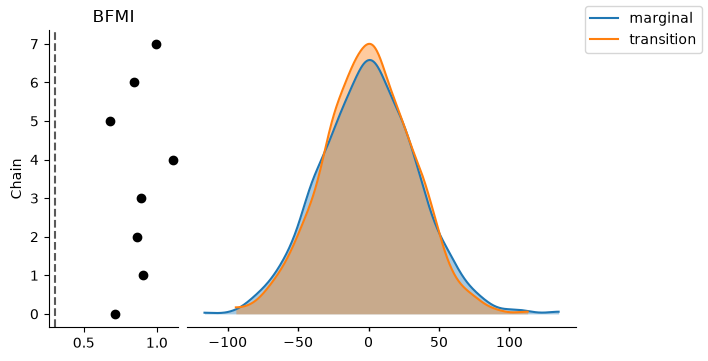

In [7]:
diagnostics = summarize(idata, [*PARAMETERS, "latent", "country_offset"])[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

## What the posterior predicts

The same three checks as before. The latents change what the coefficients mean and leave what the count model can fit as it was, so these should look like notebook 02.

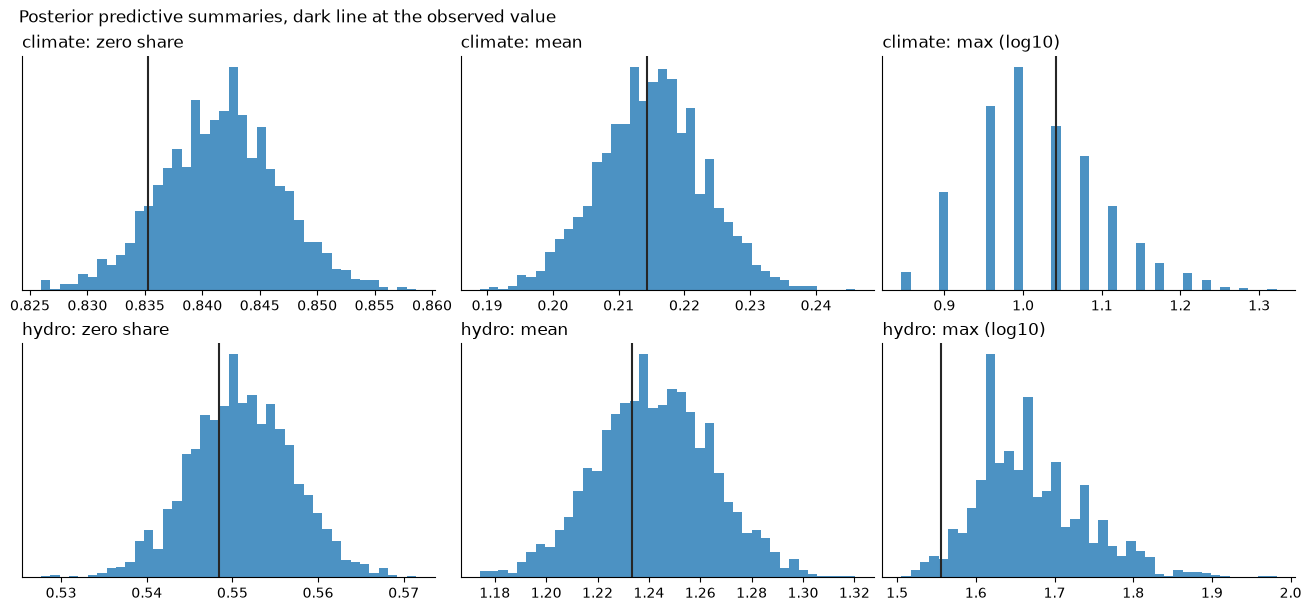

In [8]:
posterior_y = idata.posterior_predictive["y"]
plot_predictive_summaries(count_summaries(posterior_y),
                          observed_summaries,
                          CLASSES,
                          "Posterior predictive summaries, dark line at the observed value")

### The count distribution

Predicted frequency per count with its interval, observed as points, on a square-root axis.

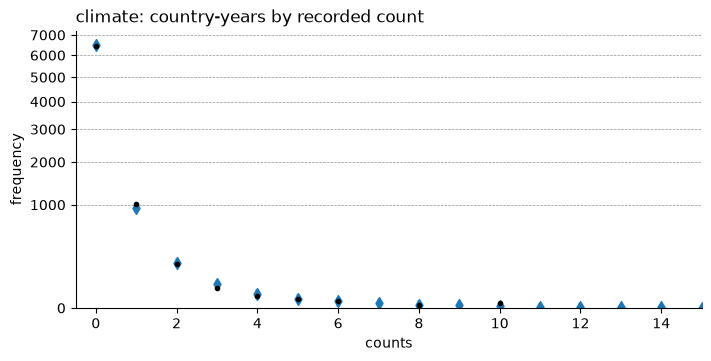

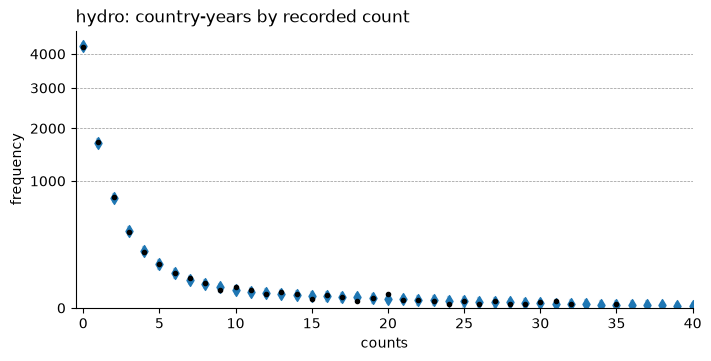

In [9]:
plot_rootograms(idata, counts, CLASSES)

### Interval coverage

Actual coverage minus nominal at every interval width, per country-year on the top row and per country total on the bottom, with the 99% band a calibrated model would produce. As in notebook 02, the country totals are over-covered by construction once each country has its own intercept, and the row is there for comparison with notebook 02.

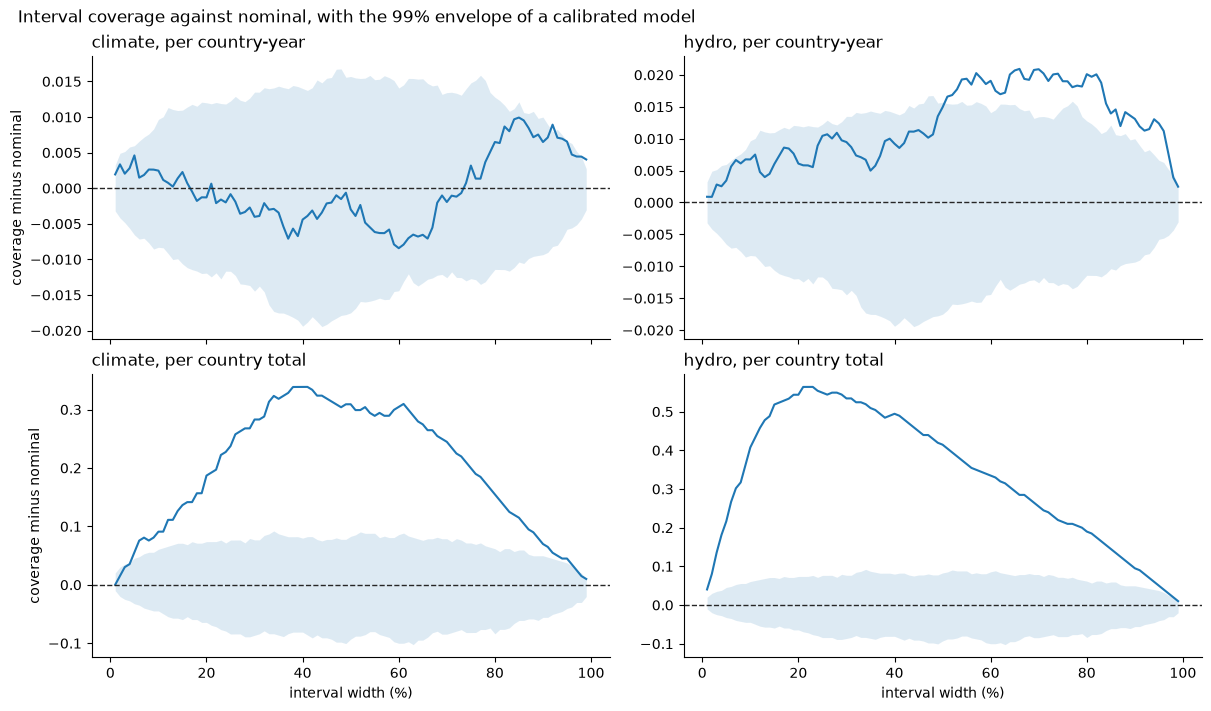

In [10]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

## Between against within

The two coefficients for each confounded covariate and class, side by side, with 94% intervals, and the within coefficients for the other two covariates. A pair that agrees is a covariate whose cross-sectional and time-series effects are the same. A pair that disagrees is one where being a richer country and becoming a richer country do different things to the recorded count, and the between coefficient carries the confounding that a country intercept was built to remove. The within coefficients against their values in notebook 02 say what changed once the cross-sectional part was taken out.

The correlation matrix of the latents follows. It is the answer to whether one country-level cause moves all three covariates.

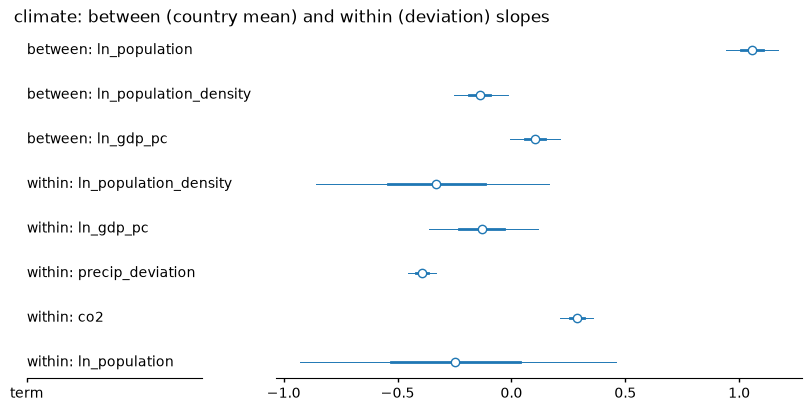

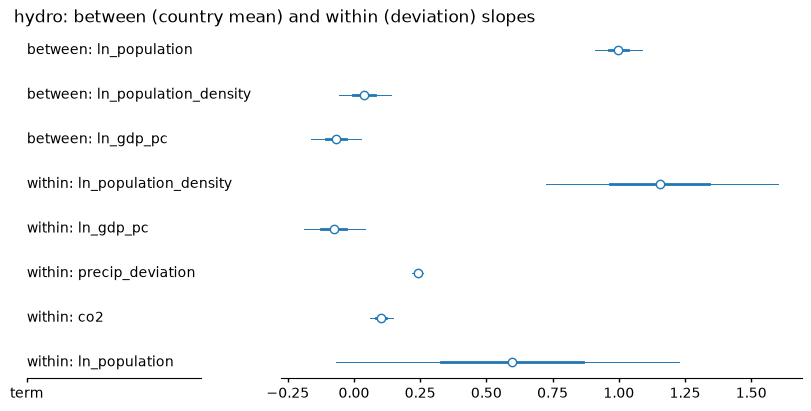

confounded_,ln_population,ln_population_density,ln_gdp_pc
confounded,,,
ln_population,1.00,-0.13,-0.27
ln_population_density,-0.13,1.00,0.16
ln_gdp_pc,-0.27,0.16,1.00


In [11]:
between = idata.posterior["beta_between"].rename(confounded="term")
between = between.assign_coords(term=[f"between: {name}" for name in between["term"].to_numpy()])
within = idata.posterior["beta_within"].rename(feature="term")
within = within.assign_coords(term=[f"within: {name}" for name in within["term"].to_numpy()])
slopes = xr.concat([between, within], dim="term").to_dataset(name="slope")

for name in CLASSES:
    grid = plot_forest(slopes,
                       coords={"disaster": name},
                       combined=True,
                       labels=["term"],
                       backend="matplotlib",
                       figure_kwargs={"figsize": (8, 4)})
    grid.viz["figure"].item().suptitle(f"{name}: between (country mean) and within (deviation) slopes",
                                       x=0.01,
                                       ha="left")
plt.show()

idata.posterior["latent_corr"].mean(dim=["chain", "draw"]).to_pandas().round(2)

## A few countries over time

The same three countries, for comparison with notebook 02.

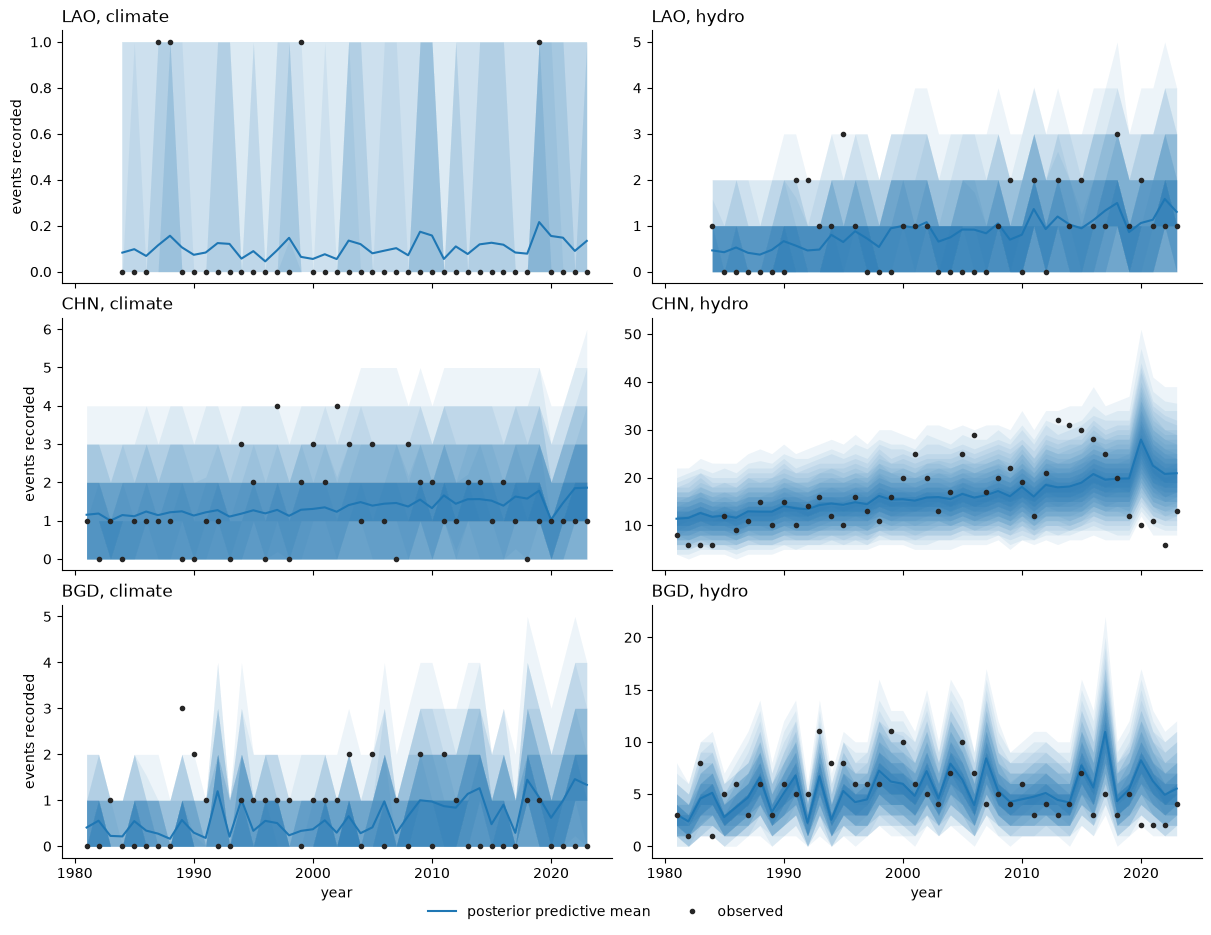

In [12]:
plot_country_counts(posterior_y, panel, counts, ["LAO", "CHN", "BGD"], CLASSES)

## The posterior against the prior

Each panel is the posterior of one parameter in blue over its prior in orange.

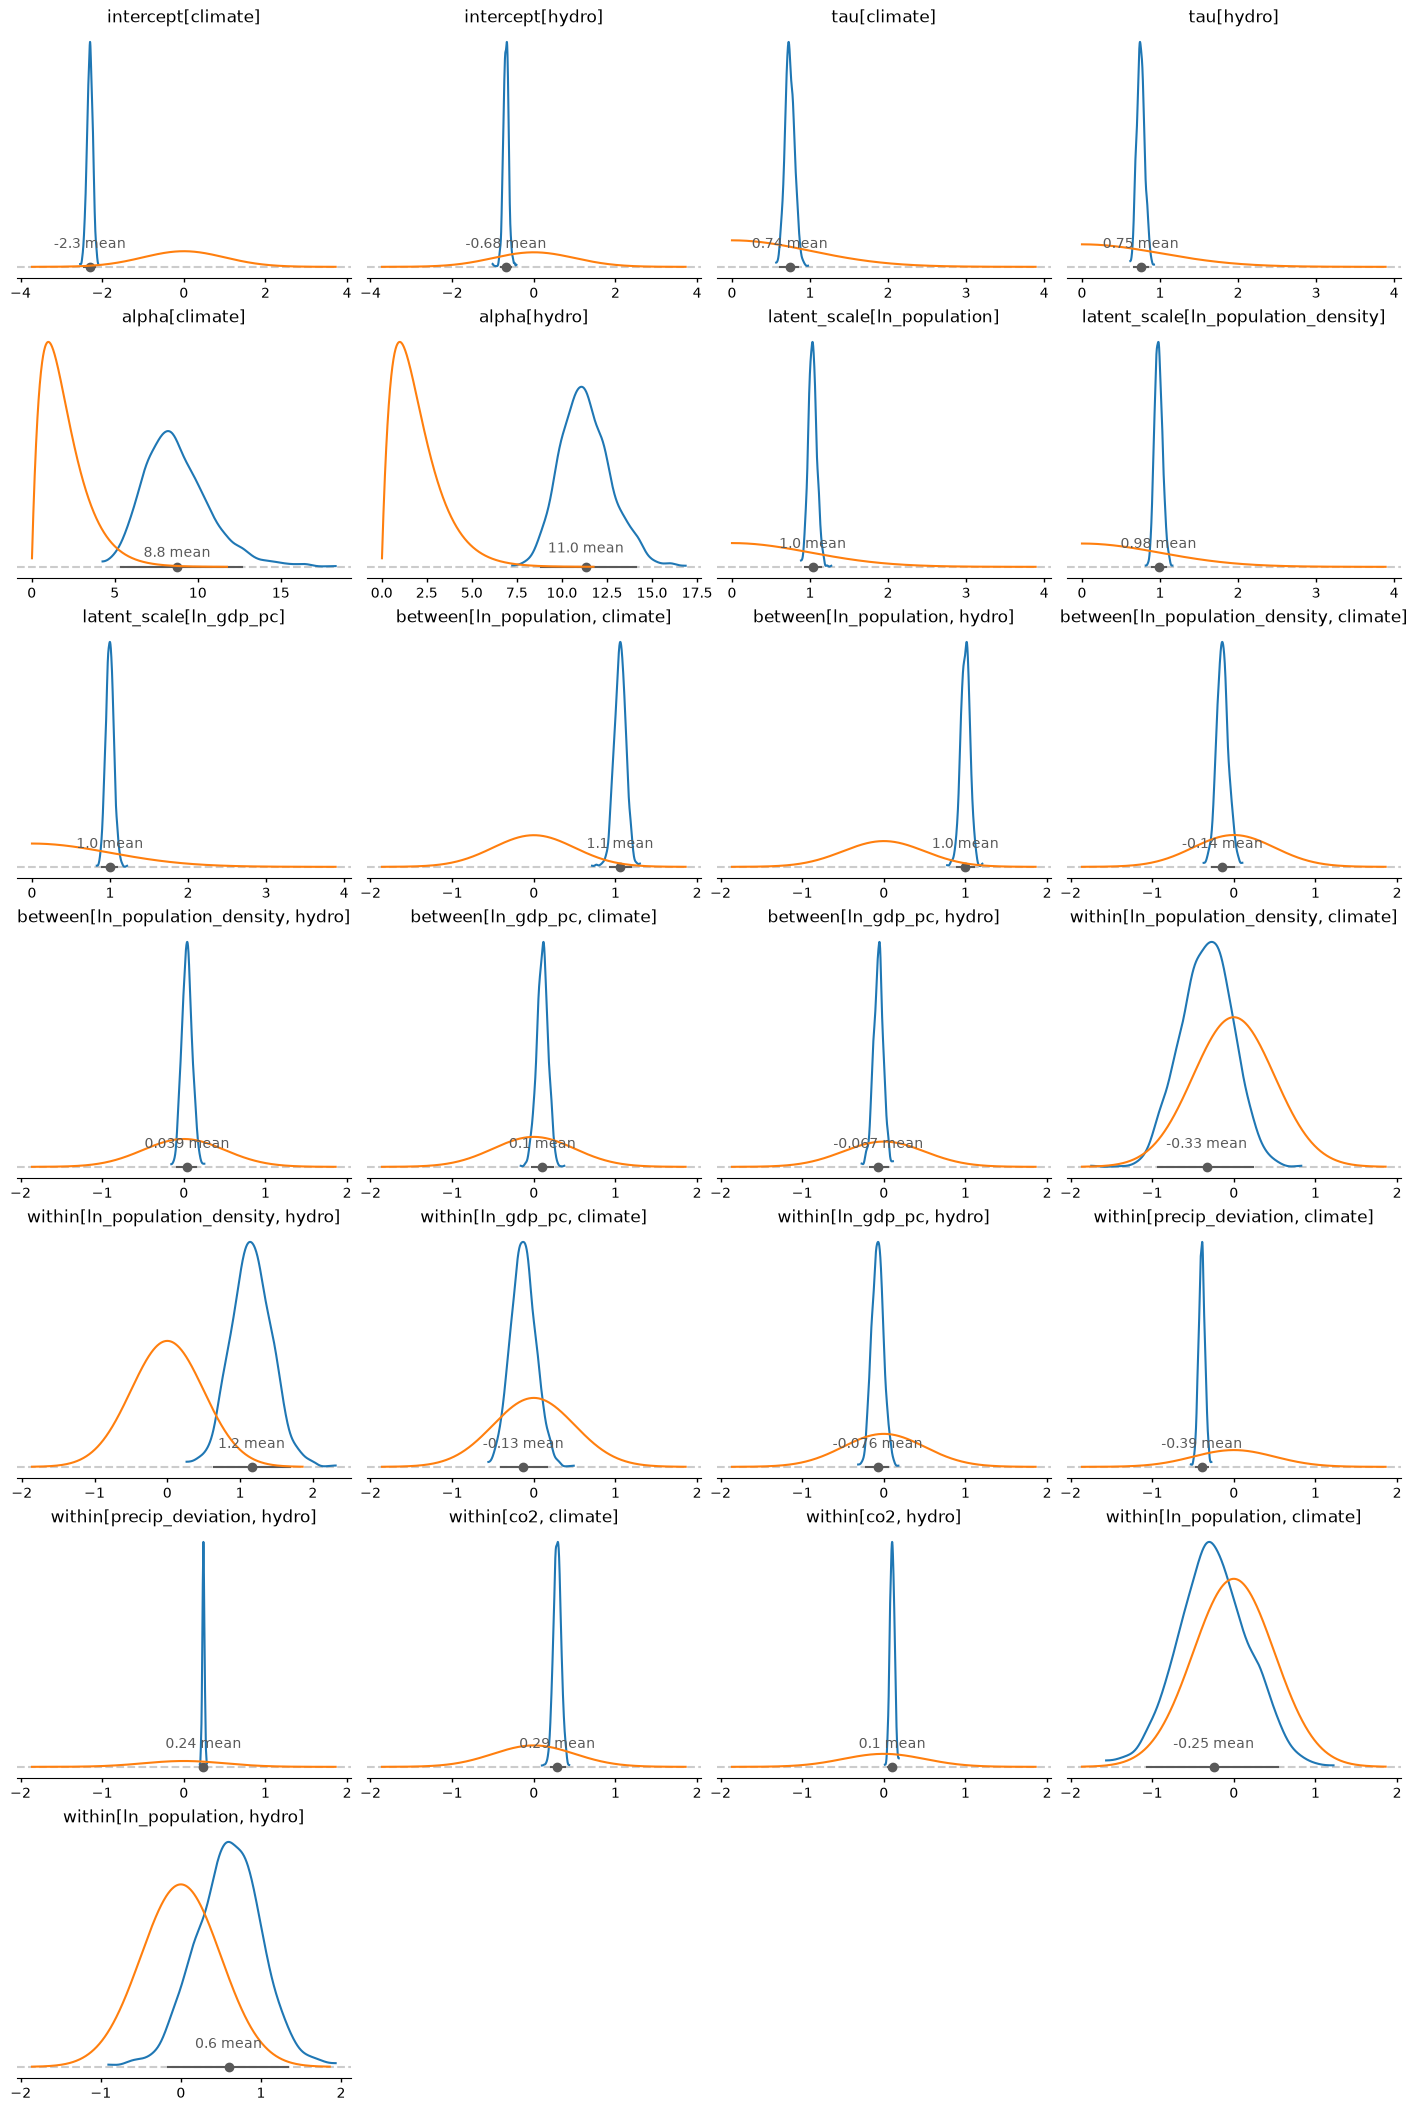

In [13]:
posterior = idata.posterior
of_interest = xr.Dataset({
    **{f"intercept[{name}]": posterior["intercept"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"tau[{name}]": posterior["tau"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"latent_scale[{name}]": posterior["latent_scale"].sel(confounded=name, drop=True) for name in CONFOUNDED},
    **{f"between[{feature}, {name}]": posterior["beta_between"].sel(confounded=feature, disaster=name, drop=True)
       for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": posterior["beta_within"].sel(feature=feature, disaster=name, drop=True)
       for feature in FEATURES for name in CLASSES},
})

priors = {
    **{f"intercept[{name}]": pz.Normal(0, 1) for name in CLASSES},
    **{f"tau[{name}]": pz.HalfNormal(1) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
    **{f"latent_scale[{name}]": pz.HalfNormal(1) for name in CONFOUNDED},
    **{f"between[{feature}, {name}]": pz.Normal(0, 0.5) for feature in CONFOUNDED for name in CLASSES},
    **{f"within[{feature}, {name}]": pz.Normal(0, 0.5) for feature in FEATURES for name in CLASSES},
}

plot_posterior_with_prior(of_interest, priors)
plt.show()

## Against the earlier notebooks

Leave-one-out expected log predictive density for the count, on the three fits so far. Only the `y` log likelihood enters, since this model also scores the covariates it generates and the earlier ones do not. The country-year is the unit left out, which favors any model with a country intercept: the other 42 years of a country say most of what its intercept is.

In [14]:
EARLIER_FITS = {"01 zinb glm": "zinb_glm.nc", "02 country intercept": "country_intercept.nc"}

fits = {name: az.from_netcdf(FIT_DIR / path) for name, path in EARLIER_FITS.items()}
fits["03 latent country means"] = idata

comparison = az.compare({name: az.loo(fit, var_name="y") for name, fit in fits.items()}, round_to=1)
comparison[["rank", "elpd", "se", "elpd_diff", "dse", "p"]]

,rank,elpd,se,elpd_diff,dse,p
03 latent country means,0,-11651.20,117.10,0.00,0.00,284.60
02 country intercept,1,-11664.60,117.10,-13.40,4.90,284.80
01 zinb glm,2,-12912.90,129.70,-1261.70,48.00,16.80


## What was learned

The three country means are close to uncorrelated across countries: -0.13 between population and density, -0.27 between population and GDP per capita, 0.16 between density and GDP per capita. That is why McElreath's single latent could not be fit on this panel. A rank-one $\Sigma$ needs one direction the three covariates share, and there is none, so the posterior offered the sampler three of them. Estimating $\Sigma$ removes the choice.

The between coefficient on population is 1.06 for climate and 1.00 for hydro, with a standard deviation of 0.07 either way. Recorded counts scale one for one with country population in the cross section, once a country intercept is in the model. The between coefficients on density and GDP per capita are within 0.15 of zero in every class. Being a denser or richer country does nothing to the recorded count that population and the intercept do not already carry.

The within coefficients say what notebook 02 could not. Population has 1% of its variance within countries, so its within coefficient is barely updated from the prior: -0.25 with a standard deviation of 0.43 for climate, 0.59 with 0.41 for hydro. Growth in GDP per capita has no effect on either count, -0.13 and -0.08, where notebook 02 had a pair of offsetting coefficients near 0.5 on the level and its square with an ESS of 46. That pair was a between-country curvature the square could no longer express once the intercepts absorbed the level. CO2 within a country is 0.29 for climate and 0.10 for hydro, against 0.15 and 0.19 in notebook 02, and precipitation deviation is unchanged at -0.39 and 0.24. Within-country density is 1.16 for hydro, and 1% of density's variance is within countries, so that number describes a handful of country trends and should not be read as an elasticity.

Nothing else moved. The intercepts, the country scale of 0.75, and the dispersions of 8.8 and 11.3 match notebook 02 to the second digit, and so does the posterior predictive. The rootograms fit, the country-year coverage is inside the band for climate and 1 to 2 points over for hydro, and the country totals are over-covered as they were in notebook 02. The country plots still show CHN's hydro record above the intervals through the 2010s and below them after: the model gets the level of each country right and the timing of its events wrong, and no cross-sectional term can repair that.

The comparison agrees. The country intercept was worth 1260 units of leave-one-out elpd over the GLM, with 285 effective parameters against 17. Splitting between from within adds 13 more with a standard error of 5, at the same effective parameter count, and the gain is the within GDP pair no longer overfitting.

The next notebook takes up time. CHN's hydro counts rise to 2015 and fall after, and the model follows the rise through CO2 and population but not the fall, so a shared year effect or a country trend is the next thing to try.